# PCA demonstration
By: Hoang Dinh<br>
2026/04/15

This is a demonstration of PCA (https://github.com/hvdinh16/temporary/blob/main/PCA.ipynb), which can be used as a standard analysis for metabolomics analysis involving more than two groups of samples. The dataset being analyzed is Dimpi's cancer and flavins. Going forward, you can start from this template. If you are comfortable with R, I think AI might be able to convert this scripts to R.

For this particular example, what are extracted from this dataset is:
* Replicates clustered well
* PC1 represents differences between KPC and KPL, driving by abundances of amino acids and amino sugars
* PC2 represents differences between depletion (dark color, down-low) and supplementation (lighter colors, up-top), driving by abundances of nucleotides, peptides, and phospholipids precursors
* PC3 represents differences between KPC day 4 vs. 8 under depletion. It is unclear what supplementation do to make it become in-between. This is driven by glycolytic intermediates, PPP intermediates. L-cystine is here.

Further examination of the raw data will be required as quality check. Metabolites might be drop if they're outliers. But per PC loadings, there seems to be no outliers.

In [155]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"

In [145]:
df_data = pd.read_excel('./20260327_KPL-KPC_Scan1-2.xlsx', sheet_name='Scan1')
#df_data2 = pd.read_excel('./20260327_KPL-KPC_Scan1-2.xlsx', sheet_name='Scan2')
#df_data = pd.concat([df_data, df_data2])

cols_drop = ['B3','B2','B1','PC2-NEM','PC1', 'SP8','SP7','SP6','SP5','SP4','SP3','SP2','SP1']
cols_drop += [c for c in df_data.columns if '-NEM' in c]
df_data.drop(cols_drop, axis=1, inplace=True)
cols_data = df_data.columns[1:]

mets_drop = []
rows_drop = df_data[df_data.Metabolites.isin(mets_drop)].index
df_data.drop(rows_drop, axis=0, inplace=True)

In [146]:
idx_drop = []
print('Row counts before row drop:', df_data.shape[0])

# Drop low intensity
data = df_data.loc[:, cols_data]
data = data.fillna(0)
means = data.mean(axis=1)
idx_drop += means[means < 1e4].index.to_list()

# Drop duplicates
df_dupl = df_data[df_data.Metabolites.duplicated(keep=False)]
mets_dupl = set(df_dupl.Metabolites)
idx_keep = []
for m in mets_dupl:
    df = df_data[df_data.Metabolites == m]
    means = data.loc[df.index, cols_data].mean(axis=1)
    idx_keep.append(means.idxmax())
idx_drop += [i for i in df_dupl.index if i not in idx_keep]

print('Dropping:', idx_drop)
df_data.drop(idx_drop, axis=0, inplace=True)
print('Row counts after row drop:', df_data.shape[0])

df_data.loc[:, cols_data] = df_data.loc[:, cols_data].fillna(0) + 1e4
print('Fill void with zero, then bump all by 1e4')

Row counts before row drop: 286
Dropping: [28, 55, 61, 62, 92, 96, 102, 180, 203, 235, 1, 25, 57, 58, 67, 68, 70, 77, 78, 86, 87, 92, 104, 105, 113, 115, 125, 126, 133, 148, 149, 152, 156, 166, 172, 191, 194, 203, 205, 222, 233, 239, 244, 247, 248, 252, 253, 257, 258, 262, 264, 265, 267, 268, 271, 274, 275, 278, 279, 280]
Row counts after row drop: 228
Fill void with zero, then bump all by 1e4


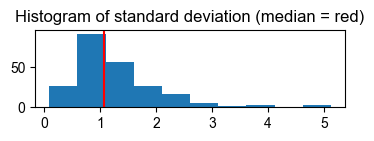

In [202]:
# Log2 adjustment
data = df_data.loc[:, cols_data]
data = np.log2(data)

log2tic = data.copy()
log2tic.index = df_data.Metabolites.to_list()

# Mean center adjustment
data = data.sub(data.mean(axis=1), axis=0)

# Get median standard deviation
stds = data.std(axis=1)
std_md = stds.median()

fig,ax = plt.subplots(figsize=(4,1))
ax.hist(stds)
ax.axvline(std_md, color='r')
ax.set_title('Histogram of standard deviation (median = red)');

# Z-normalization by median std
data = data / std_md

In [193]:
# Performing PCA on rescaled data
from sklearn.preprocessing import StandardScaler
x = data.T
x = StandardScaler().fit_transform(x)

from sklearn.decomposition import PCA
N_pc = 5
pca = PCA(n_components=N_pc)
pcomps = pca.fit_transform(x)

pcs = ['PC'+str(i) for i in range(1,N_pc+1)]
df_pc = pd.DataFrame(data=pcomps, columns=pcs)
df_pc['Sample'] = cols_data

print('PCA explained variance ratio')
pca.explained_variance_ratio_

PCA explained variance ratio


array([0.49253337, 0.17504281, 0.10966111, 0.04494255, 0.03254586])

In [194]:
# Make groups
labels = pd.Series(index=cols_data, dtype=str)
for c in cols_data:
    plast = c.split('-')[-1]
    labels[c] = c[:-len(plast)-1]

df_pc['Label'] = labels.to_list()
label_set = sorted(list(set(labels)))
print('You have to assign colors for these label:', label_set)

colors_dict = {
'KPC-Day4_Ctrl': '#ffcc80',
 'KPC-Day4_FAD': '#ffa726',
 'KPC-Day4_FMN': '#fb8c00',
 'KPC-Day4_RBFdep': '#ef6c00',
 
 'KPC-Day8_Ctrl': '#ffcdd2',
 'KPC-Day8_FAD': '#e57373',
 'KPC-Day8_FMN': '#f44336',
 'KPC-Day8_RBFdep': '#d32f2f',
 
 'KPL-Day2_Ctrl': '#bbdefb',
 'KPL-Day2_FAD': '#64b5f6',
 'KPL-Day2_FMN': '#2196f3',
 'KPL-Day2_RBFdep': '#1976d2',
 
 'KPL-Day4_Ctrl': '#80deea',
 'KPL-Day4_FAD': '#26c6da',
 'KPL-Day4_FMN': '#00acc1',
 'KPL-Day4_RBFdep': '#00838f'
}

You have to assign colors for these label: ['KPC-Day4_Ctrl', 'KPC-Day4_FAD', 'KPC-Day4_FMN', 'KPC-Day4_RBFdep', 'KPC-Day8_Ctrl', 'KPC-Day8_FAD', 'KPC-Day8_FMN', 'KPC-Day8_RBFdep', 'KPL-Day2_Ctrl', 'KPL-Day2_FAD', 'KPL-Day2_FMN', 'KPL-Day2_RBFdep', 'KPL-Day4_Ctrl', 'KPL-Day4_FAD', 'KPL-Day4_FMN', 'KPL-Day4_RBFdep']


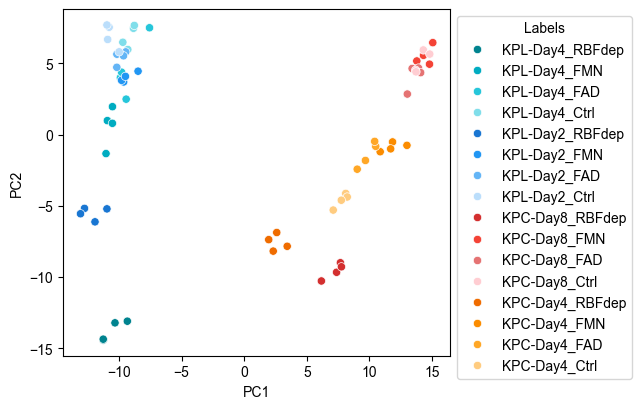

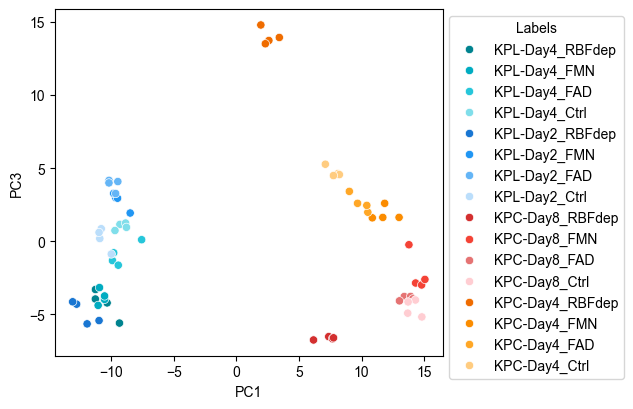

In [195]:
for xlabel,ylabel in [('PC1','PC2'), ('PC1','PC3')]:
    fig,ax = plt.subplots(figsize=(5, 0.9*5))
    sns.scatterplot(data=df_pc, x=xlabel, y=ylabel,
                    hue='Label', palette=colors_dict)
    plt.legend(title="Labels", loc='upper left', bbox_to_anchor=(1, 1))

In [196]:
# Get and plot loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=pcs, index=df_data.Metabolites.to_list())

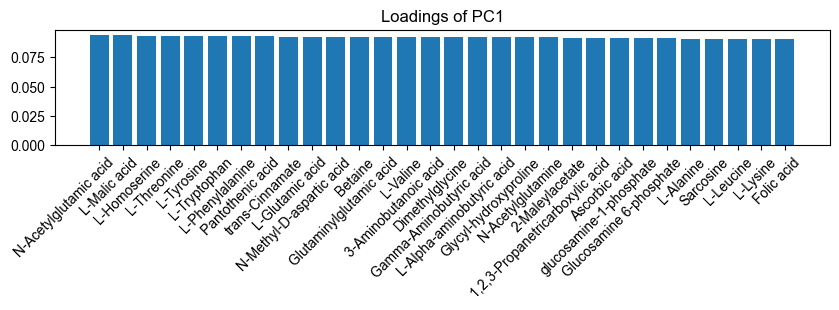

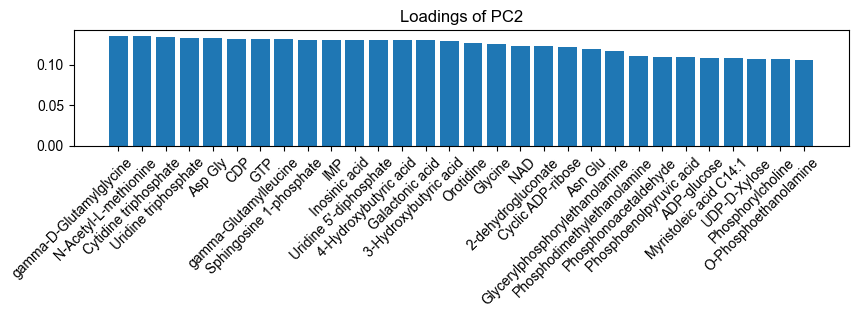

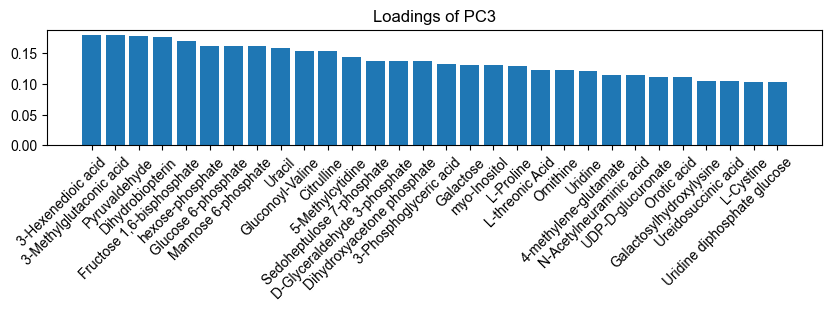

In [197]:
N_plot = 30

for pc in ['PC1', 'PC2', 'PC3']:
    vals = loadings[pc]
    idx = vals.abs().sort_values(ascending=False).index[:N_plot]

    fig,ax = plt.subplots(figsize=(10,1.5))
    xs = range(0, len(idx))
    ys = vals.abs()[idx]
    ax.bar(xs, ys)

    ax.set_xticks(xs)
    ax.set_xticklabels(idx, ha='right', rotation_mode='anchor');
    
    from matplotlib.transforms import ScaledTranslation
    offset = ScaledTranslation(0.075, 0, fig.dpi_scale_trans)
    for label_obj in ax.get_xticklabels():
        label_obj.set_rotation(45)
        label_obj.set_transform(label_obj.get_transform() + offset)

    ax.set_title('Loadings of ' + pc)

Text(0.5, 1.0, 'L-Phenylalanine')

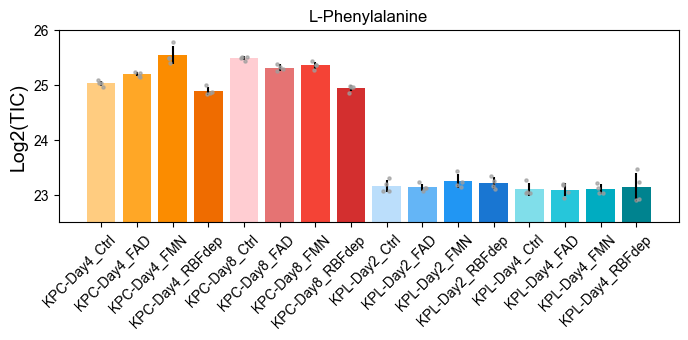

In [227]:
# A representative metabolite of PC1
# KPC vs. KPL cell line differences
met = 'L-Phenylalanine'
fig,ax = plt.subplots(figsize=(8, 2.5))

label_set = sorted(list(set(labels)))

for i,l in enumerate(label_set):
    reps = labels[labels == l].index
    vals = log2tic.loc[met, reps]
    m = vals.mean(); std = vals.std(ddof=1)
    
    ax.bar(i, m, yerr=std, color=colors_dict[l])
    
    jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
    x_coords = [i] * len(vals) + jitter
    ax.scatter(x_coords, vals, color='#9e9e9e', s=5, alpha=0.7, zorder=3)

ax.set_ylim(22.5, 26)

xs = range(0, len(label_set))
ax.set_xticks(xs)
ax.set_xticklabels(label_set, ha='right', rotation_mode='anchor');

from matplotlib.transforms import ScaledTranslation
offset = ScaledTranslation(0.075, 0, fig.dpi_scale_trans)
for label_obj in ax.get_xticklabels():
    label_obj.set_rotation(45)
    label_obj.set_transform(label_obj.get_transform() + offset)

ax.set_ylabel('Log2(TIC)', fontsize=14)
ax.set_title(met)

Text(0.5, 1.0, 'Cytidine triphosphate')

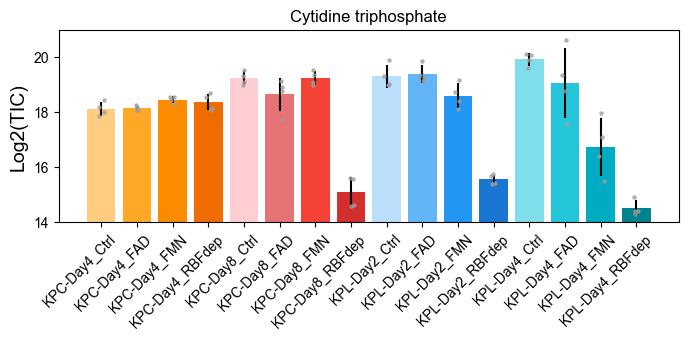

In [228]:
# A representative metabolite of PC2
# Depletion vs. supplementation differences
met = 'Cytidine triphosphate'
fig,ax = plt.subplots(figsize=(8, 2.5))

label_set = sorted(list(set(labels)))

for i,l in enumerate(label_set):
    reps = labels[labels == l].index
    vals = log2tic.loc[met, reps]
    m = vals.mean(); std = vals.std(ddof=1)
    
    ax.bar(i, m, yerr=std, color=colors_dict[l])
    
    jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
    x_coords = [i] * len(vals) + jitter
    ax.scatter(x_coords, vals, color='#9e9e9e', s=5, alpha=0.7, zorder=3)

ax.set_ylim(14, 21)

xs = range(0, len(label_set))
ax.set_xticks(xs)
ax.set_xticklabels(label_set, ha='right', rotation_mode='anchor');

from matplotlib.transforms import ScaledTranslation
offset = ScaledTranslation(0.075, 0, fig.dpi_scale_trans)
for label_obj in ax.get_xticklabels():
    label_obj.set_rotation(45)
    label_obj.set_transform(label_obj.get_transform() + offset)

ax.set_ylabel('Log2(TIC)', fontsize=14)
ax.set_title(met)

Text(0.5, 1.0, 'Glucose 6-phosphate')

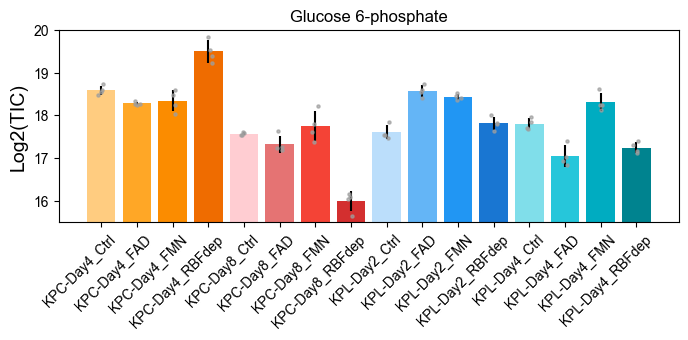

In [232]:
# A representative metabolite of PC3
# KPC day 4 vs. day 8 differences
met = 'Glucose 6-phosphate'
fig,ax = plt.subplots(figsize=(8, 2.5))

label_set = sorted(list(set(labels)))

for i,l in enumerate(label_set):
    reps = labels[labels == l].index
    vals = log2tic.loc[met, reps]
    m = vals.mean(); std = vals.std(ddof=1)
    
    ax.bar(i, m, yerr=std, color=colors_dict[l])
    
    jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
    x_coords = [i] * len(vals) + jitter
    ax.scatter(x_coords, vals, color='#9e9e9e', s=5, alpha=0.7, zorder=3)

ax.set_ylim(15.5, 20)

xs = range(0, len(label_set))
ax.set_xticks(xs)
ax.set_xticklabels(label_set, ha='right', rotation_mode='anchor');

from matplotlib.transforms import ScaledTranslation
offset = ScaledTranslation(0.075, 0, fig.dpi_scale_trans)
for label_obj in ax.get_xticklabels():
    label_obj.set_rotation(45)
    label_obj.set_transform(label_obj.get_transform() + offset)

ax.set_ylabel('Log2(TIC)', fontsize=14)
ax.set_title(met)